<a href="https://colab.research.google.com/github/saiDan77/nn-from-scratch/blob/main/1M_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# ONE TRANSFORMER BLOCK — FROM SCRATCH
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import math

# ------------------------------------------------------------
# 1. CONFIGURATION
# ------------------------------------------------------------

B = 2       # batch size
T = 16      # sequence length / context used in this test
D = 288     # model dimension
H = 6       # attention heads
F_DIM = 1408 # FFN dimension

assert D % H == 0

HEAD_DIM = D // H

print("=" * 70)
print("CONFIGURATION")
print("=" * 70)

print(f"Batch size       B = {B}")
print(f"Sequence length  T = {T}")
print(f"Model dimension   D = {D}")
print(f"Attention heads   H = {H}")
print(f"FFN dimension     F = {F_DIM}")
print(f"Head dimension D/H  = {HEAD_DIM}")


# ============================================================
# 2. RMS NORM
# ============================================================

class RMSNorm(nn.Module):

    def __init__(self, dim, eps=1e-6):

        super().__init__()

        self.eps = eps

        # One learned scale for every model dimension.
        #
        # If D = 288:
        #
        # weight shape = [288]
        #
        self.weight = nn.Parameter(
            torch.ones(dim)
        )

    def forward(self, x):

        # x shape:
        #
        # [B, T, D]
        #
        # Example:
        #
        # [2, 16, 288]

        rms = torch.sqrt(
            x.pow(2).mean(dim=-1, keepdim=True)
            + self.eps
        )

        x = x / rms

        return x * self.weight


# ============================================================
# 3. SELF ATTENTION
# ============================================================

class SelfAttention(nn.Module):

    def __init__(self, D, H):

        super().__init__()

        assert D % H == 0

        self.D = D
        self.H = H
        self.head_dim = D // H

        # ----------------------------------------------------
        # Q, K, V projections
        #
        # D → D
        #
        # Each matrix:
        #
        # [288, 288]
        # ----------------------------------------------------

        self.Wq = nn.Linear(
            D, D, bias=False
        )

        self.Wk = nn.Linear(
            D, D, bias=False
        )

        self.Wv = nn.Linear(
            D, D, bias=False
        )

        # ----------------------------------------------------
        # Output projection
        #
        # D → D
        #
        # [288, 288]
        # ----------------------------------------------------

        self.Wo = nn.Linear(
            D, D, bias=False
        )

    def forward(self, x):

        # ----------------------------------------------------
        # INPUT
        # ----------------------------------------------------

        # x:
        #
        # [B, T, D]
        #
        # [2, 16, 288]

        B, T, D = x.shape

        print("\nATTENTION")

        print("Input X       :", x.shape)

        # ----------------------------------------------------
        # CREATE Q, K, V
        # ----------------------------------------------------

        q = self.Wq(x)
        k = self.Wk(x)
        v = self.Wv(x)

        print("Q             :", q.shape)
        print("K             :", k.shape)
        print("V             :", v.shape)

        # Still:
        #
        # [B, T, D]
        #
        # [2, 16, 288]

        # ----------------------------------------------------
        # SPLIT INTO HEADS
        # ----------------------------------------------------

        # We want:
        #
        # [B, T, H, HEAD_DIM]
        #
        # [2, 16, 6, 48]

        q = q.view(
            B, T, self.H, self.head_dim
        )

        k = k.view(
            B, T, self.H, self.head_dim
        )

        v = v.view(
            B, T, self.H, self.head_dim
        )

        print("\nAfter splitting heads:")

        print("Q             :", q.shape)
        print("K             :", k.shape)
        print("V             :", v.shape)

        # ----------------------------------------------------
        # MOVE HEAD BEFORE SEQUENCE
        # ----------------------------------------------------

        # From:
        #
        # [B, T, H, Hd]
        #
        # To:
        #
        # [B, H, T, Hd]

        q = q.transpose(1, 2)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)

        print("\nAfter transpose:")

        print("Q             :", q.shape)
        print("K             :", k.shape)
        print("V             :", v.shape)

        # Example:
        #
        # [2, 6, 16, 48]

        # ----------------------------------------------------
        # ATTENTION SCORES
        # ----------------------------------------------------

        # Q:
        #
        # [B, H, T, Hd]
        #
        # K.transpose:
        #
        # [B, H, Hd, T]
        #
        # Result:
        #
        # [B, H, T, T]
        #
        # [2, 6, 16, 16]

        scores = (
            q @ k.transpose(-2, -1)
        ) / math.sqrt(self.head_dim)

        print("\nAttention scores:")
        print("scores        :", scores.shape)

        # ----------------------------------------------------
        # CAUSAL MASK
        # ----------------------------------------------------

        # A language model must not see future tokens.
        #
        # For example:
        #
        # Token 3 cannot look at token 4.
        #
        # Token 3 CAN look at tokens 1, 2, 3.
        #
        # So we create a lower-triangular mask.

        mask = torch.tril(
            torch.ones(
                T, T,
                device=x.device,
                dtype=torch.bool
            )
        )

        # Future positions become -infinity.
        #
        # softmax(-infinity) ≈ 0

        scores = scores.masked_fill(
            ~mask,
            float("-inf")
        )

        # ----------------------------------------------------
        # SOFTMAX
        # ----------------------------------------------------

        attention_weights = F.softmax(
            scores,
            dim=-1
        )

        print(
            "attention     :",
            attention_weights.shape
        )

        # ----------------------------------------------------
        # ATTENTION × VALUE
        # ----------------------------------------------------

        # [B,H,T,T] @ [B,H,T,Hd]
        #
        # →
        #
        # [B,H,T,Hd]

        out = attention_weights @ v

        print(
            "Head output   :",
            out.shape
        )

        # ----------------------------------------------------
        # MERGE HEADS
        # ----------------------------------------------------

        # Current:
        #
        # [B,H,T,Hd]
        #
        # Move back:
        #
        # [B,T,H,Hd]

        out = out.transpose(1, 2)

        # Merge H × Hd:
        #
        # 6 × 48 = 288

        out = out.contiguous().view(
            B, T, D
        )

        print(
            "Merged output  :",
            out.shape
        )

        # ----------------------------------------------------
        # OUTPUT PROJECTION
        # ----------------------------------------------------

        out = self.Wo(out)

        print(
            "After Wo      :",
            out.shape
        )

        return out


# ============================================================
# 4. FEED-FORWARD NETWORK
# ============================================================

class FeedForward(nn.Module):

    def __init__(self, D, F_DIM):

        super().__init__()

        # D → F
        #
        # [288, 1408]

        self.W1 = nn.Linear(
            D,
            F_DIM,
            bias=False
        )

        # F → D
        #
        # [1408, 288]

        self.W2 = nn.Linear(
            F_DIM,
            D,
            bias=False
        )

    def forward(self, x):

        print("\nFEED-FORWARD NETWORK")

        print(
            "Input         :",
            x.shape
        )

        x = self.W1(x)

        print(
            "After W1      :",
            x.shape
        )

        # GELU is the nonlinear activation.
        #
        # Without a nonlinear activation,
        # two linear layers would effectively
        # collapse into one linear transformation.

        x = F.gelu(x)

        print(
            "After GELU    :",
            x.shape
        )

        x = self.W2(x)

        print(
            "After W2      :",
            x.shape
        )

        return x


# ============================================================
# 5. COMPLETE TRANSFORMER BLOCK
# ============================================================

class TransformerBlock(nn.Module):

    def __init__(self, D, H, F_DIM):

        super().__init__()

        self.norm1 = RMSNorm(D)

        self.attention = SelfAttention(
            D,
            H
        )

        self.norm2 = RMSNorm(D)

        self.ffn = FeedForward(
            D,
            F_DIM
        )

    def forward(self, x):

        print("\n")
        print("=" * 70)
        print("TRANSFORMER BLOCK")
        print("=" * 70)

        print("\nOriginal X:", x.shape)

        # ----------------------------------------------------
        # FIRST SUBLAYER
        #
        # X → Norm → Attention → + X
        # ----------------------------------------------------

        attention_output = self.attention(
            self.norm1(x)
        )

        x = x + attention_output

        print(
            "\nAfter attention residual:",
            x.shape
        )

        # ----------------------------------------------------
        # SECOND SUBLAYER
        #
        # X → Norm → FFN → + X
        # ----------------------------------------------------

        ffn_output = self.ffn(
            self.norm2(x)
        )

        x = x + ffn_output

        print(
            "\nAfter FFN residual:",
            x.shape
        )

        return x


# ============================================================
# 6. CREATE RANDOM INPUT
# ============================================================

print("\n")
print("=" * 70)
print("CREATING INPUT")
print("=" * 70)

x = torch.randn(
    B,
    T,
    D
)

print(
    f"Random input shape: {x.shape}"
)

# ============================================================
# 7. CREATE BLOCK
# ============================================================

block = TransformerBlock(
    D=D,
    H=H,
    F_DIM=F_DIM
)

# ============================================================
# 8. RUN FORWARD PASS
# ============================================================

output = block(x)

# ============================================================
# 9. FINAL RESULT
# ============================================================

print("\n")
print("=" * 70)
print("FINAL RESULT")
print("=" * 70)

print()

print(
    "Input shape :",
    x.shape
)

print(
    "Output shape:",
    output.shape
)

print()

print(
    "Notice:"
)

print(
    "Input and output have EXACTLY the same shape."
)

print(
    f"[B, T, D] = [{B}, {T}, {D}]"
)

print()

# ============================================================
# 10. PARAMETER COUNT
# ============================================================

print("=" * 70)
print("PARAMETERS")
print("=" * 70)

total_params = sum(
    p.numel()
    for p in block.parameters()
)

print(
    f"Actual PyTorch block parameters: "
    f"{total_params:,}"
)

print(
    f"Actual PyTorch block parameters: "
    f"{total_params/1e6:.3f}M"
)

print()

print(
    "Approximate calculation:"
)

approx_attention = 4 * D * D
approx_ffn = 2 * D * F_DIM

print(
    f"Attention ≈ {approx_attention:,}"
)

print(
    f"FFN       ≈ {approx_ffn:,}"
)

print(
    f"Block     ≈ "
    f"{approx_attention + approx_ffn:,}"
)

CONFIGURATION
Batch size       B = 2
Sequence length  T = 16
Model dimension   D = 288
Attention heads   H = 6
FFN dimension     F = 1408
Head dimension D/H  = 48


CREATING INPUT
Random input shape: torch.Size([2, 16, 288])


TRANSFORMER BLOCK

Original X: torch.Size([2, 16, 288])

ATTENTION
Input X       : torch.Size([2, 16, 288])
Q             : torch.Size([2, 16, 288])
K             : torch.Size([2, 16, 288])
V             : torch.Size([2, 16, 288])

After splitting heads:
Q             : torch.Size([2, 16, 6, 48])
K             : torch.Size([2, 16, 6, 48])
V             : torch.Size([2, 16, 6, 48])

After transpose:
Q             : torch.Size([2, 6, 16, 48])
K             : torch.Size([2, 6, 16, 48])
V             : torch.Size([2, 6, 16, 48])

Attention scores:
scores        : torch.Size([2, 6, 16, 16])
attention     : torch.Size([2, 6, 16, 16])
Head output   : torch.Size([2, 6, 16, 48])
Merged output  : torch.Size([2, 16, 288])
After Wo      : torch.Size([2, 16, 288])

After atte

In [2]:
# ============================================================
# COMPLETE TINY DECODER-ONLY LANGUAGE MODEL
# FROM TOKEN IDs → NEXT TOKEN LOGITS
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import math

# ============================================================
# 1. CONFIG
# ============================================================

VOCAB_SIZE = 256

MAX_SEQ_LEN = 128

D = 128
H = 4
F_DIM = 512
L = 5

assert D % H == 0

HEAD_DIM = D // H

print("=" * 70)
print("MODEL CONFIGURATION")
print("=" * 70)

print(f"Vocabulary       V = {VOCAB_SIZE}")
print(f"Context length   T = {MAX_SEQ_LEN}")
print(f"Model dimension  D = {D}")
print(f"Attention heads  H = {H}")
print(f"Head dimension     = {HEAD_DIM}")
print(f"FFN dimension    F = {F_DIM}")
print(f"Layers           L = {L}")


# ============================================================
# 2. RMS NORM
# ============================================================

class RMSNorm(nn.Module):

    def __init__(self, dim, eps=1e-6):

        super().__init__()

        self.eps = eps

        self.weight = nn.Parameter(
            torch.ones(dim)
        )

    def forward(self, x):

        rms = torch.sqrt(
            x.pow(2).mean(
                dim=-1,
                keepdim=True
            )
            + self.eps
        )

        return (
            x / rms
        ) * self.weight


# ============================================================
# 3. SELF ATTENTION
# ============================================================

class SelfAttention(nn.Module):

    def __init__(self, D, H, max_seq_len):

        super().__init__()

        assert D % H == 0

        self.D = D
        self.H = H
        self.head_dim = D // H

        # Q K V O
        #
        # D → D
        #
        # Each is [D, D]

        self.q_proj = nn.Linear(
            D, D, bias=False
        )

        self.k_proj = nn.Linear(
            D, D, bias=False
        )

        self.v_proj = nn.Linear(
            D, D, bias=False
        )

        self.o_proj = nn.Linear(
            D, D, bias=False
        )

        # ----------------------------------------------------
        # CAUSAL MASK
        # ----------------------------------------------------

        mask = torch.tril(
            torch.ones(
                max_seq_len,
                max_seq_len
            )
        )

        self.register_buffer(
            "mask",
            mask
        )

    def forward(self, x):

        B, T, D = x.shape

        # ----------------------------------------------------
        # Q K V
        # ----------------------------------------------------

        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)

        # [B,T,D]
        #
        # → [B,T,H,head_dim]

        q = q.view(
            B,
            T,
            self.H,
            self.head_dim
        )

        k = k.view(
            B,
            T,
            self.H,
            self.head_dim
        )

        v = v.view(
            B,
            T,
            self.H,
            self.head_dim
        )

        # [B,T,H,Hd]
        #
        # →
        #
        # [B,H,T,Hd]

        q = q.transpose(1, 2)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)

        # ----------------------------------------------------
        # ATTENTION SCORES
        # ----------------------------------------------------

        scores = (
            q @ k.transpose(-2, -1)
        ) / math.sqrt(self.head_dim)

        # scores:
        #
        # [B,H,T,T]

        # ----------------------------------------------------
        # CAUSAL MASK
        # ----------------------------------------------------

        causal_mask = (
            self.mask[:T, :T]
            .bool()
        )

        scores = scores.masked_fill(
            ~causal_mask,
            float("-inf")
        )

        # ----------------------------------------------------
        # SOFTMAX
        # ----------------------------------------------------

        weights = F.softmax(
            scores,
            dim=-1
        )

        # ----------------------------------------------------
        # WEIGHTED VALUES
        # ----------------------------------------------------

        out = weights @ v

        # [B,H,T,Hd]
        #
        # →
        #
        # [B,T,H,Hd]

        out = out.transpose(1, 2)

        # →
        #
        # [B,T,D]

        out = out.contiguous().view(
            B,
            T,
            D
        )

        # ----------------------------------------------------
        # OUTPUT PROJECTION
        # ----------------------------------------------------

        return self.o_proj(out)


# ============================================================
# 4. FEED FORWARD
# ============================================================

class FeedForward(nn.Module):

    def __init__(self, D, F_DIM):

        super().__init__()

        self.fc1 = nn.Linear(
            D,
            F_DIM,
            bias=False
        )

        self.fc2 = nn.Linear(
            F_DIM,
            D,
            bias=False
        )

    def forward(self, x):

        x = self.fc1(x)

        x = F.gelu(x)

        x = self.fc2(x)

        return x


# ============================================================
# 5. TRANSFORMER BLOCK
# ============================================================

class TransformerBlock(nn.Module):

    def __init__(
        self,
        D,
        H,
        F_DIM,
        max_seq_len
    ):

        super().__init__()

        self.norm1 = RMSNorm(D)

        self.attention = SelfAttention(
            D,
            H,
            max_seq_len
        )

        self.norm2 = RMSNorm(D)

        self.ffn = FeedForward(
            D,
            F_DIM
        )

    def forward(self, x):

        # ----------------------------------------------------
        # ATTENTION + RESIDUAL
        # ----------------------------------------------------

        x = x + self.attention(
            self.norm1(x)
        )

        # ----------------------------------------------------
        # FFN + RESIDUAL
        # ----------------------------------------------------

        x = x + self.ffn(
            self.norm2(x)
        )

        return x


# ============================================================
# 6. COMPLETE LANGUAGE MODEL
# ============================================================

class TinyLanguageModel(nn.Module):

    def __init__(
        self,
        vocab_size,
        max_seq_len,
        D,
        H,
        F_DIM,
        L
    ):

        super().__init__()

        self.vocab_size = vocab_size

        self.max_seq_len = max_seq_len

        self.D = D

        # ----------------------------------------------------
        # TOKEN EMBEDDING
        # ----------------------------------------------------

        self.token_embedding = nn.Embedding(
            vocab_size,
            D
        )

        # ----------------------------------------------------
        # POSITION EMBEDDING
        #
        # One learned vector per position.
        #
        # [T,D]
        # ----------------------------------------------------

        self.position_embedding = nn.Embedding(
            max_seq_len,
            D
        )

        # ----------------------------------------------------
        # TRANSFORMER BLOCKS
        # ----------------------------------------------------

        self.blocks = nn.ModuleList(
            [
                TransformerBlock(
                    D=D,
                    H=H,
                    F_DIM=F_DIM,
                    max_seq_len=max_seq_len
                )
                for _ in range(L)
            ]
        )

        # ----------------------------------------------------
        # FINAL NORMALIZATION
        # ----------------------------------------------------

        self.final_norm = RMSNorm(D)

        # ----------------------------------------------------
        # LANGUAGE MODEL HEAD
        #
        # D → V
        #
        # ----------------------------------------------------

        self.lm_head = nn.Linear(
            D,
            vocab_size,
            bias=False
        )

    def forward(self, tokens):

        B, T = tokens.shape

        assert T <= self.max_seq_len

        # ----------------------------------------------------
        # TOKEN EMBEDDINGS
        # ----------------------------------------------------

        token_emb = self.token_embedding(
            tokens
        )

        # Shape:
        #
        # [B,T,D]

        # ----------------------------------------------------
        # POSITION EMBEDDINGS
        # ----------------------------------------------------

        positions = torch.arange(
            T,
            device=tokens.device
        )

        pos_emb = self.position_embedding(
            positions
        )

        # Shape:
        #
        # [T,D]

        # Broadcasting:
        #
        # [B,T,D]
        # +
        # [T,D]
        #
        # →
        #
        # [B,T,D]

        x = token_emb + pos_emb

        # ----------------------------------------------------
        # TRANSFORMER
        # ----------------------------------------------------

        for block in self.blocks:

            x = block(x)

        # ----------------------------------------------------
        # FINAL NORM
        # ----------------------------------------------------

        x = self.final_norm(x)

        # ----------------------------------------------------
        # LM HEAD
        # ----------------------------------------------------

        logits = self.lm_head(x)

        # Shape:
        #
        # [B,T,V]

        return logits


# ============================================================
# 7. CREATE MODEL
# ============================================================

model = TinyLanguageModel(
    vocab_size=VOCAB_SIZE,
    max_seq_len=MAX_SEQ_LEN,
    D=D,
    H=H,
    F_DIM=F_DIM,
    L=L
)


# ============================================================
# 8. COUNT PARAMETERS
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print()
print("=" * 70)
print("PARAMETER COUNT")
print("=" * 70)

print(
    f"Total parameters: "
    f"{total_params:,}"
)

print(
    f"Total parameters: "
    f"{total_params / 1e6:.3f}M"
)


# ============================================================
# 9. SHOW PARAMETER GROUPS
# ============================================================

print()
print("=" * 70)
print("PARAMETER GROUPS")
print("=" * 70)

groups = {}

for name, param in model.named_parameters():

    group = name.split(".")[0]

    groups[group] = (
        groups.get(group, 0)
        + param.numel()
    )

for name, count in groups.items():

    print(
        f"{name:<25}"
        f"{count:>12,}"
        f"   ({count/total_params*100:5.1f}%)"
    )


# ============================================================
# 10. CREATE FAKE TOKEN DATA
# ============================================================

BATCH_SIZE = 2
SEQ_LEN = 32

tokens = torch.randint(
    0,
    VOCAB_SIZE,
    (
        BATCH_SIZE,
        SEQ_LEN
    )
)

print()
print("=" * 70)
print("INPUT")
print("=" * 70)

print(
    "Token IDs shape:",
    tokens.shape
)

print(
    "Example tokens:",
    tokens[0, :10]
)


# ============================================================
# 11. FORWARD PASS
# ============================================================

logits = model(tokens)

print()
print("=" * 70)
print("MODEL OUTPUT")
print("=" * 70)

print(
    "Logits shape:",
    logits.shape
)

print(
    f"""
Meaning:

Batch      = {BATCH_SIZE}
Sequence   = {SEQ_LEN}
Vocabulary = {VOCAB_SIZE}

Therefore:

[B, T, V]
=
[{BATCH_SIZE}, {SEQ_LEN}, {VOCAB_SIZE}]
"""
)


# ============================================================
# 12. LOOK AT ONE TOKEN'S PREDICTION
# ============================================================

position = 5

token_logits = logits[
    0,
    position
]

print("=" * 70)
print("ONE TOKEN PREDICTION")
print("=" * 70)

print(
    "Logits for one position:",
    token_logits.shape
)

# Convert scores → probabilities

probs = F.softmax(
    token_logits,
    dim=-1
)

top_probs, top_tokens = torch.topk(
    probs,
    k=10
)

print()
print("Top 10 predicted token IDs:")

for token_id, probability in zip(
    top_tokens.tolist(),
    top_probs.tolist()
):

    print(
        f"Token {token_id:4d}"
        f"   probability = {probability:.4f}"
    )


# ============================================================
# 13. NEXT-TOKEN TRAINING LOSS
# ============================================================

# Language modeling:

#
# Input:
#
#   A B C D E
#
# Target:
#
#   B C D E F
#
# We shift the sequence by one position.

input_tokens = tokens[:, :-1]

target_tokens = tokens[:, 1:]

logits = model(
    input_tokens
)

B2, T2, V2 = logits.shape

loss = F.cross_entropy(
    logits.reshape(
        -1,
        V2
    ),
    target_tokens.reshape(
        -1
    )
)

print()
print("=" * 70)
print("NEXT TOKEN LOSS")
print("=" * 70)

print(
    "Input shape:",
    input_tokens.shape
)

print(
    "Target shape:",
    target_tokens.shape
)

print(
    "Logits shape:",
    logits.shape
)

print(
    f"Cross-entropy loss: {loss.item():.4f}"
)

print()
print(
    "The model is now producing a probability "
    "distribution for the next token."
)

MODEL CONFIGURATION
Vocabulary       V = 256
Context length   T = 128
Model dimension  D = 128
Attention heads  H = 4
Head dimension     = 32
FFN dimension    F = 512
Layers           L = 5

PARAMETER COUNT
Total parameters: 1,066,368
Total parameters: 1.066M

PARAMETER GROUPS
token_embedding                32,768   (  3.1%)
position_embedding             16,384   (  1.5%)
blocks                        984,320   ( 92.3%)
final_norm                        128   (  0.0%)
lm_head                        32,768   (  3.1%)

INPUT
Token IDs shape: torch.Size([2, 32])
Example tokens: tensor([ 86, 170, 172, 216, 204,  61,  35, 239,  18, 135])

MODEL OUTPUT
Logits shape: torch.Size([2, 32, 256])

Meaning:

Batch      = 2
Sequence   = 32
Vocabulary = 256

Therefore:

[B, T, V]
=
[2, 32, 256]

ONE TOKEN PREDICTION
Logits for one position: torch.Size([256])

Top 10 predicted token IDs:
Token   84   probability = 0.0159
Token   92   probability = 0.0141
Token  184   probability = 0.0141
Token  215  

Device: cpu

Parameters: 1066368
Parameters (M): 1.066368
step    1 | loss 5.7010 | time 0.5s
step   50 | loss 5.5641 | time 19.2s
step  100 | loss 5.5472 | time 39.5s
step  150 | loss 5.5500 | time 58.0s
step  200 | loss 5.5465 | time 77.6s
step  250 | loss 5.5486 | time 96.2s
step  300 | loss 5.5437 | time 115.8s
step  350 | loss 5.5483 | time 134.4s
step  400 | loss 5.5496 | time 153.9s
step  450 | loss 5.5463 | time 172.4s
step  500 | loss 5.5425 | time 192.1s
step  550 | loss 5.5462 | time 210.6s
step  600 | loss 5.5475 | time 230.3s
step  650 | loss 5.5466 | time 248.9s
step  700 | loss 5.5500 | time 268.5s
step  750 | loss 5.5440 | time 287.2s
step  800 | loss 5.5447 | time 306.2s
step  850 | loss 5.5454 | time 325.3s
step  900 | loss 5.5402 | time 343.9s
step  950 | loss 5.5484 | time 363.4s
step 1000 | loss 5.5403 | time 382.0s


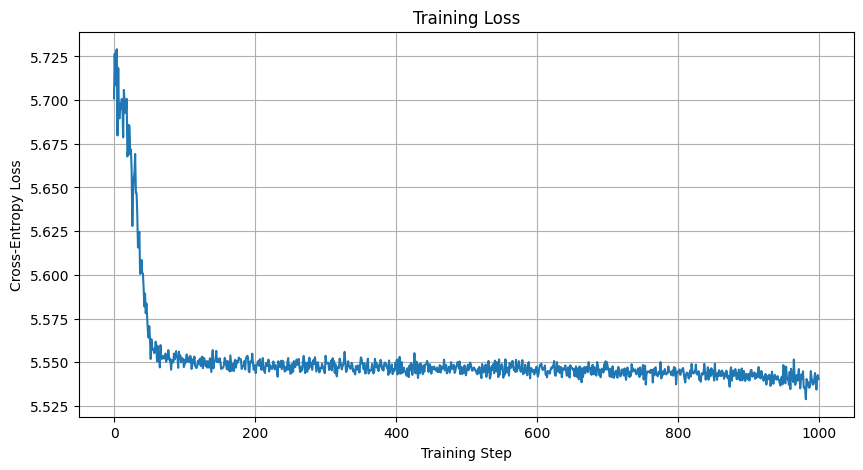


VALIDATION
Validation loss: 5.5579
Perplexity: 259.28

GRADIENT INSPECTION
token_embedding.weight                       mean grad = 0.000009
position_embedding.weight                    mean grad = 0.000013
blocks.0.norm1.weight                        mean grad = 0.000014

IMPORTANT

This model is NOT learning useful language.

Why?

Because the training data is random.

There is no meaningful relationship between:

token_t → token_(t+1)

So this experiment teaches us the MECHANICS:

    data
      ↓
    forward
      ↓
    loss
      ↓
    backward
      ↓
    gradients
      ↓
    optimizer
      ↓
    updated parameters

Next we replace the random data with REAL TEXT.



In [4]:
# ============================================================
# TRAINING A TINY LANGUAGE MODEL FROM SCRATCH
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import time

# ============================================================
# 1. DEVICE
# ============================================================

device = (
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


# ============================================================
# 2. CONFIGURATION
# ============================================================

VOCAB_SIZE = 256
MAX_SEQ_LEN = 128

D = 128
H = 4
F_DIM = 512
L = 5

BATCH_SIZE = 16

TRAIN_STEPS = 1000

LEARNING_RATE = 3e-4

WEIGHT_DECAY = 0.1

LOG_EVERY = 50


# ============================================================
# 3. MODEL
# ============================================================

class RMSNorm(nn.Module):

    def __init__(self, dim, eps=1e-6):

        super().__init__()

        self.eps = eps

        self.weight = nn.Parameter(
            torch.ones(dim)
        )

    def forward(self, x):

        rms = torch.sqrt(
            x.pow(2).mean(
                dim=-1,
                keepdim=True
            )
            + self.eps
        )

        return (
            x / rms
        ) * self.weight


class SelfAttention(nn.Module):

    def __init__(
        self,
        D,
        H,
        max_seq_len
    ):

        super().__init__()

        assert D % H == 0

        self.D = D
        self.H = H
        self.head_dim = D // H

        self.q_proj = nn.Linear(
            D,
            D,
            bias=False
        )

        self.k_proj = nn.Linear(
            D,
            D,
            bias=False
        )

        self.v_proj = nn.Linear(
            D,
            D,
            bias=False
        )

        self.o_proj = nn.Linear(
            D,
            D,
            bias=False
        )

        mask = torch.tril(
            torch.ones(
                max_seq_len,
                max_seq_len
            )
        )

        self.register_buffer(
            "mask",
            mask
        )

    def forward(self, x):

        B, T, D = x.shape

        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)

        q = q.view(
            B,
            T,
            self.H,
            self.head_dim
        ).transpose(1, 2)

        k = k.view(
            B,
            T,
            self.H,
            self.head_dim
        ).transpose(1, 2)

        v = v.view(
            B,
            T,
            self.H,
            self.head_dim
        ).transpose(1, 2)

        scores = (
            q @ k.transpose(-2, -1)
        ) / math.sqrt(
            self.head_dim
        )

        scores = scores.masked_fill(
            ~self.mask[:T, :T].bool(),
            float("-inf")
        )

        weights = F.softmax(
            scores,
            dim=-1
        )

        out = weights @ v

        out = out.transpose(
            1,
            2
        ).contiguous().view(
            B,
            T,
            D
        )

        return self.o_proj(out)


class FeedForward(nn.Module):

    def __init__(
        self,
        D,
        F_DIM
    ):

        super().__init__()

        self.fc1 = nn.Linear(
            D,
            F_DIM,
            bias=False
        )

        self.fc2 = nn.Linear(
            F_DIM,
            D,
            bias=False
        )

    def forward(self, x):

        x = self.fc1(x)

        x = F.gelu(x)

        x = self.fc2(x)

        return x


class TransformerBlock(nn.Module):

    def __init__(
        self,
        D,
        H,
        F_DIM,
        max_seq_len
    ):

        super().__init__()

        self.norm1 = RMSNorm(D)

        self.attention = SelfAttention(
            D,
            H,
            max_seq_len
        )

        self.norm2 = RMSNorm(D)

        self.ffn = FeedForward(
            D,
            F_DIM
        )

    def forward(self, x):

        x = x + self.attention(
            self.norm1(x)
        )

        x = x + self.ffn(
            self.norm2(x)
        )

        return x


class TinyLanguageModel(nn.Module):

    def __init__(
        self,
        vocab_size,
        max_seq_len,
        D,
        H,
        F_DIM,
        L
    ):

        super().__init__()

        self.token_embedding = nn.Embedding(
            vocab_size,
            D
        )

        self.position_embedding = nn.Embedding(
            max_seq_len,
            D
        )

        self.blocks = nn.ModuleList([
            TransformerBlock(
                D,
                H,
                F_DIM,
                max_seq_len
            )
            for _ in range(L)
        ])

        self.final_norm = RMSNorm(D)

        self.lm_head = nn.Linear(
            D,
            vocab_size,
            bias=False
        )

    def forward(self, tokens):

        B, T = tokens.shape

        positions = torch.arange(
            T,
            device=tokens.device
        )

        x = (
            self.token_embedding(tokens)
            +
            self.position_embedding(
                positions
            )
        )

        for block in self.blocks:

            x = block(x)

        x = self.final_norm(x)

        logits = self.lm_head(x)

        return logits


# ============================================================
# 4. CREATE MODEL
# ============================================================

model = TinyLanguageModel(
    VOCAB_SIZE,
    MAX_SEQ_LEN,
    D,
    H,
    F_DIM,
    L
).to(device)


# ============================================================
# 5. PARAMETER COUNT
# ============================================================

num_params = sum(
    p.numel()
    for p in model.parameters()
)

print()
print("Parameters:", num_params)
print(
    "Parameters (M):",
    num_params / 1e6
)


# ============================================================
# 6. CREATE SYNTHETIC DATA
# ============================================================

DATA_SIZE = 200_000

data = torch.randint(
    0,
    VOCAB_SIZE,
    (DATA_SIZE,)
)

split = int(
    DATA_SIZE * 0.9
)

train_data = data[:split]

val_data = data[split:]


# ============================================================
# 7. BATCH FUNCTION
# ============================================================

def get_batch(
    data,
    batch_size,
    seq_len
):

    starts = torch.randint(
        0,
        len(data) - seq_len - 1,
        (batch_size,)
    )

    x = torch.stack([
        data[
            i:i + seq_len
        ]
        for i in starts
    ])

    y = torch.stack([
        data[
            i + 1:i + seq_len + 1
        ]
        for i in starts
    ])

    return (
        x.to(device),
        y.to(device)
    )


# ============================================================
# 8. OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)


# ============================================================
# 9. TRAINING
# ============================================================

model.train()

loss_history = []

start_time = time.time()

for step in range(
    1,
    TRAIN_STEPS + 1
):

    # --------------------------------------------------------
    # GET DATA - Fixed unpacking
    # --------------------------------------------------------

    x, y = get_batch(
        train_data,
        BATCH_SIZE,
        MAX_SEQ_LEN
    )

    # --------------------------------------------------------
    # FORWARD
    # --------------------------------------------------------

    logits = model(x)

    loss = F.cross_entropy(
        logits.reshape(
            -1,
            VOCAB_SIZE
        ),
        y.reshape(-1)
    )

    # --------------------------------------------------------
    # BACKWARD
    # --------------------------------------------------------

    optimizer.zero_grad(
        set_to_none=True
    )

    loss.backward()

    # --------------------------------------------------------
    # GRADIENT CLIPPING
    # --------------------------------------------------------

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        1.0
    )

    # --------------------------------------------------------
    # UPDATE
    # --------------------------------------------------------

    optimizer.step()

    loss_history.append(
        loss.item()
    )

    # --------------------------------------------------------
    # LOG
    # --------------------------------------------------------

    if step == 1 or step % LOG_EVERY == 0:

        elapsed = (
            time.time()
            - start_time
        )

        print(
            f"step {step:4d} | "
            f"loss {loss.item():.4f} | "
            f"time {elapsed:.1f}s"
        )


# ============================================================
# 10. TRAINING CURVE
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    loss_history
)

plt.xlabel(
    "Training Step"
)

plt.ylabel(
    "Cross-Entropy Loss"
)

plt.title(
    "Training Loss"
)

plt.grid()

plt.show()


# ============================================================
# 11. VALIDATION LOSS
# ============================================================

@torch.no_grad()
def evaluate(
    model,
    data,
    batches=20
):

    model.eval()

    losses = []

    for _ in range(batches):

        x, y = get_batch(
            data,
            BATCH_SIZE,
            MAX_SEQ_LEN
        )

        logits = model(x)

        loss = F.cross_entropy(
            logits.reshape(
                -1,
                VOCAB_SIZE
            ),
            y.reshape(-1)
        )

        losses.append(
            loss.item()
        )

    model.train()

    return sum(losses) / len(losses)


val_loss = evaluate(
    model,
    val_data
)

print()
print("=" * 70)
print("VALIDATION")
print("=" * 70)

print(
    f"Validation loss: {val_loss:.4f}"
)

print(
    f"Perplexity: {math.exp(val_loss):.2f}"
)


# ============================================================
# 12. INSPECT GRADIENTS
# ============================================================

print()
print("=" * 70)
print("GRADIENT INSPECTION")
print("=" * 70)

for name, param in model.named_parameters():

    if param.grad is not None:

        print(
            f"{name:<45}"
            f"mean grad = "
            f"{param.grad.abs().mean().item():.6f}"
        )

        if name.count(".") > 2:

            break


# ============================================================
# 13. IMPORTANT OBSERVATION
# ============================================================

print()
print("=" * 70)
print("IMPORTANT")
print("=" * 70)

print(
"""
This model is NOT learning useful language.

Why?

Because the training data is random.

There is no meaningful relationship between:

token_t → token_(t+1)

So this experiment teaches us the MECHANICS:

    data
      ↓
    forward
      ↓
    loss
      ↓
    backward
      ↓
    gradients
      ↓
    optimizer
      ↓
    updated parameters

Next we replace the random data with REAL TEXT.
"""
)